In [2]:
import pandas as pd
import os

os.chdir(r"C:\Users\steph\Downloads\retention_project")
%pip install openpyxl

import matplotlib.pyplot as plt
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pd.ExcelFile(
    r"C:\Users\steph\Downloads\retention_project\retention_table.xlsx", 
).sheet_names

['Sheet6', 'Sheet7', 'Sheet8', 'Sheet9', 'bq-results-20260817-223908-1787']

Read file

In [4]:
df = pd.read_excel(r"C:\Users\steph\Downloads\retention_project\retention_table.xlsx", sheet_name="bq-results-20260817-223908-1787")

In [5]:
df2 = pd.read_excel(r"C:\Users\steph\Downloads\retention_project\retention_table_7days.xlsx", sheet_name="bq-results-20260821-030146-1787")

In [6]:
df2

,user_pseudo_id,event_timestamp,user_first_touch_timestamp,event_name
0,810460BCE8FD8E5E12852CED0025B836,1535630753716001,1535314216596000,level_up
1,810460BCE8FD8E5E12852CED0025B836,1535630751061000,1535314216596000,level_complete
2,8F75FAE8C9129A7B666A7DBA014898E4,1535656549265004,1535569050216000,level_up
3,8F75FAE8C9129A7B666A7DBA014898E4,1535655508936016,1535569050216000,level_start
4,58B7ED321E8361D3FBACF4DF4E549399,1535685423182001,1535121933734000,level_up
...,...,...,...,...
83097,38D65030548914B5E167CE85B035CA8F,1533757999624091,1533498054672000,level_retry_quickplay
83098,E2A653542E03CF823E7F19FE9CD209AC,1533750525013020,1533205134946000,level_start
83099,C1B1A57BFD7A3176CB7C587FF29653C6,1533750865364022,1533499566709000,level_complete_quickplay
83100,DF2FC56E807EAF16E852AEAB67E0127A,1533765445257095,1533420969615000,level_fail


In [7]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 83102 entries, 0 to 83101
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   user_pseudo_id              83102 non-null  str  
 1   event_timestamp             83102 non-null  int64
 2   user_first_touch_timestamp  83102 non-null  int64
 3   event_name                  83102 non-null  str  
dtypes: int64(2), str(2)
memory usage: 2.5 MB


Scientific Notation to Float

In [8]:
pd.set_option("display.float_format", "{:,.2f}".format)


Part 1: More data cleaning and fixing datatypes for further analysis

In [9]:
df


,user_pseudo_id,event_timestamp,event_date,event_name,user_first_touch_timestamp,platform,operating_system,country,source,version
0,310228A29216613C01B08D8B37AA21E1,"1,535,658,508,686,015.00","20,180,830.00",level_up,"1,535,625,377,504,000.00",ANDROID,ANDROID,Argentina,google-play,2.62
1,310228A29216613C01B08D8B37AA21E1,"1,535,664,334,241,136.00","20,180,830.00",level_up,"1,535,625,377,504,000.00",ANDROID,ANDROID,Argentina,google-play,2.62
2,310228A29216613C01B08D8B37AA21E1,"1,535,658,259,326,048.00","20,180,830.00",level_retry,"1,535,625,377,504,000.00",ANDROID,ANDROID,Argentina,google-play,2.62
3,310228A29216613C01B08D8B37AA21E1,"1,535,664,538,436,185.00","20,180,830.00",level_retry,"1,535,625,377,504,000.00",ANDROID,ANDROID,Argentina,google-play,2.62
4,A14518C766440EB6F1E2F2105CDE37F9,"1,535,685,792,860,000.00","20,180,830.00",level_complete,"1,535,685,376,981,000.00",ANDROID,ANDROID,United States,google-play,2.62
...,...,...,...,...,...,...,...,...,...,...
138739,378D3B51D99A076B2E978EDB669581D0,"1,533,780,829,067,011.00","20,180,808.00",level_start_quickplay,"1,533,779,956,716,000.00",ANDROID,ANDROID,United States,google-play,2.62
138740,E325A12D5EBC55ACEC787D88E545A9F0,"1,533,712,754,447,080.00","20,180,808.00",level_fail_quickplay,"1,533,712,270,454,000.00",ANDROID,ANDROID,United States,google-play,2.62
138741,E325A12D5EBC55ACEC787D88E545A9F0,"1,533,712,365,552,028.00","20,180,808.00",level_start_quickplay,"1,533,712,270,454,000.00",ANDROID,ANDROID,United States,google-play,2.62
138742,EEE628A485F44D66C44261AFA8FF8AEA,"1,533,780,219,422,038.00","20,180,808.00",level_retry,"1,533,779,575,767,000.00",ANDROID,IOS,United States,(direct),2.6.31


In [10]:
print(df["event_date"])

0        20,180,830.00
1        20,180,830.00
2        20,180,830.00
3        20,180,830.00
4        20,180,830.00
              ...     
138739   20,180,808.00
138740   20,180,808.00
138741   20,180,808.00
138742   20,180,808.00
138743             NaN
Name: event_date, Length: 138744, dtype: float64


Check types

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138744 entries, 0 to 138743
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   user_pseudo_id              138743 non-null  str    
 1   event_timestamp             138743 non-null  float64
 2   event_date                  138743 non-null  float64
 3   event_name                  138743 non-null  str    
 4   user_first_touch_timestamp  138743 non-null  float64
 5   platform                    138744 non-null  str    
 6   operating_system            130641 non-null  str    
 7   country                     138713 non-null  str    
 8   source                      138369 non-null  str    
 9   version                     138743 non-null  object 
dtypes: float64(3), object(1), str(6)
memory usage: 10.6+ MB


TRIMMING

In [12]:
df["version"] = df["version"].astype("string")

In [13]:
df["version"] = df["version"].str.strip()


Data Type changes

In [14]:
df["event_date"] = pd.to_datetime(df["event_date"].astype("Int64").astype("string"), format="%Y%m%d")

Converting from microseconds to datetime

In [15]:
df["user_first_touch_timestamp"] = pd.to_datetime(
    df["user_first_touch_timestamp"],
    unit="us",
    errors="coerce"
)

Convert microseconds event timestamp to date

In [16]:
df["event_timestamp"] = pd.to_datetime(
    df["event_timestamp"],
    unit="us",
    errors="coerce"
)

In [17]:
df

,user_pseudo_id,event_timestamp,event_date,event_name,user_first_touch_timestamp,platform,operating_system,country,source,version
0,310228A29216613C01B08D8B37AA21E1,2018-08-30 19:48:28.686015,2018-08-30,level_up,2018-08-30 10:36:17.504,ANDROID,ANDROID,Argentina,google-play,2.62
1,310228A29216613C01B08D8B37AA21E1,2018-08-30 21:25:34.241136,2018-08-30,level_up,2018-08-30 10:36:17.504,ANDROID,ANDROID,Argentina,google-play,2.62
2,310228A29216613C01B08D8B37AA21E1,2018-08-30 19:44:19.326048,2018-08-30,level_retry,2018-08-30 10:36:17.504,ANDROID,ANDROID,Argentina,google-play,2.62
3,310228A29216613C01B08D8B37AA21E1,2018-08-30 21:28:58.436185,2018-08-30,level_retry,2018-08-30 10:36:17.504,ANDROID,ANDROID,Argentina,google-play,2.62
4,A14518C766440EB6F1E2F2105CDE37F9,2018-08-31 03:23:12.860000,2018-08-30,level_complete,2018-08-31 03:16:16.981,ANDROID,ANDROID,United States,google-play,2.62
...,...,...,...,...,...,...,...,...,...,...
138739,378D3B51D99A076B2E978EDB669581D0,2018-08-09 02:13:49.067011,2018-08-08,level_start_quickplay,2018-08-09 01:59:16.716,ANDROID,ANDROID,United States,google-play,2.62
138740,E325A12D5EBC55ACEC787D88E545A9F0,2018-08-08 07:19:14.447080,2018-08-08,level_fail_quickplay,2018-08-08 07:11:10.454,ANDROID,ANDROID,United States,google-play,2.62
138741,E325A12D5EBC55ACEC787D88E545A9F0,2018-08-08 07:12:45.552028,2018-08-08,level_start_quickplay,2018-08-08 07:11:10.454,ANDROID,ANDROID,United States,google-play,2.62
138742,EEE628A485F44D66C44261AFA8FF8AEA,2018-08-09 02:03:39.422038,2018-08-08,level_retry,2018-08-09 01:52:55.767,ANDROID,IOS,United States,(direct),2.6.31


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138744 entries, 0 to 138743
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   user_pseudo_id              138743 non-null  str           
 1   event_timestamp             138743 non-null  datetime64[us]
 2   event_date                  138743 non-null  datetime64[us]
 3   event_name                  138743 non-null  str           
 4   user_first_touch_timestamp  138743 non-null  datetime64[us]
 5   platform                    138744 non-null  str           
 6   operating_system            130641 non-null  str           
 7   country                     138713 non-null  str           
 8   source                      138369 non-null  str           
 9   version                     138743 non-null  string        
dtypes: datetime64[us](3), str(6), string(1)
memory usage: 10.6 MB


Part 2: Level Complete and Fail Events

In [19]:
complete = (df[df["event_name"] == "level_complete"].groupby("user_pseudo_id").size())

print(complete)

user_pseudo_id
0043CF8841C819015ACD25710D333113     3
011068A78F16C35DE89A649B12D640DA     1
01562149DD13E75D732F0A9CA2D8CF5C     8
0160043392B1572A375E5C3BE1BB0C31    30
019016F377FEFB43E822470C38EC7FD2     2
                                    ..
FFA9AE78B23263835F8AAED57713EBE9    28
FFB030A91BE1315EE25A6BA619E1D903    28
FFCB4862EE1A6728952D4B43A8005EB5     1
FFDDF354D9B9E851D2A62ABAEA17DA3E    25
FFFF9A8B436FAAA293AE33E8C6D3ED66     3
Length: 1949, dtype: int64


In [20]:
fail = (df[df["event_name"] == "level_fail"].groupby("user_pseudo_id").size())
print(fail)

user_pseudo_id
0043CF8841C819015ACD25710D333113     2
010DAA54F4C62559F2F5767813B48782     3
01562149DD13E75D732F0A9CA2D8CF5C     6
0160043392B1572A375E5C3BE1BB0C31    11
0232A0C6A31572DBA6D6CB0F2592ABCE     5
                                    ..
FF74A964AAA9943AEA2A56F6DA42D287     6
FFA9AE78B23263835F8AAED57713EBE9    48
FFB030A91BE1315EE25A6BA619E1D903     4
FFB0B799F5051FE90BDBCEBF0F2F1084     1
FFDDF354D9B9E851D2A62ABAEA17DA3E     7
Length: 1054, dtype: int64


Combine them and rename

In [21]:
features = pd.concat([complete, fail], axis=1).fillna(0)
print(features)

                                     0     1
user_pseudo_id                              
0043CF8841C819015ACD25710D333113  3.00  2.00
011068A78F16C35DE89A649B12D640DA  1.00  0.00
01562149DD13E75D732F0A9CA2D8CF5C  8.00  6.00
0160043392B1572A375E5C3BE1BB0C31 30.00 11.00
019016F377FEFB43E822470C38EC7FD2  2.00  0.00
...                                ...   ...
F6C7487E08B33808B67130FFD37DEFD9  0.00  8.00
F7612205BAFC8569AF251DAD4F4CF37E  0.00  1.00
FD18022A69269C2E16F11DDF41A64610  0.00  1.00
FF74A964AAA9943AEA2A56F6DA42D287  0.00  6.00
FFB0B799F5051FE90BDBCEBF0F2F1084  0.00  1.00

[2071 rows x 2 columns]


Fix user id to be column

In [22]:
features = features.reset_index()

In [23]:
features.columns = ["user_pseudo_id","level_complete", "level_fail"]
print(features)

                        user_pseudo_id  level_complete  level_fail
0     0043CF8841C819015ACD25710D333113            3.00        2.00
1     011068A78F16C35DE89A649B12D640DA            1.00        0.00
2     01562149DD13E75D732F0A9CA2D8CF5C            8.00        6.00
3     0160043392B1572A375E5C3BE1BB0C31           30.00       11.00
4     019016F377FEFB43E822470C38EC7FD2            2.00        0.00
...                                ...             ...         ...
2066  F6C7487E08B33808B67130FFD37DEFD9            0.00        8.00
2067  F7612205BAFC8569AF251DAD4F4CF37E            0.00        1.00
2068  FD18022A69269C2E16F11DDF41A64610            0.00        1.00
2069  FF74A964AAA9943AEA2A56F6DA42D287            0.00        6.00
2070  FFB0B799F5051FE90BDBCEBF0F2F1084            0.00        1.00

[2071 rows x 3 columns]


Part 3: Checking player retention (From first touch to next for the next 7 days)

In [24]:
df2

,user_pseudo_id,event_timestamp,user_first_touch_timestamp,event_name
0,810460BCE8FD8E5E12852CED0025B836,1535630753716001,1535314216596000,level_up
1,810460BCE8FD8E5E12852CED0025B836,1535630751061000,1535314216596000,level_complete
2,8F75FAE8C9129A7B666A7DBA014898E4,1535656549265004,1535569050216000,level_up
3,8F75FAE8C9129A7B666A7DBA014898E4,1535655508936016,1535569050216000,level_start
4,58B7ED321E8361D3FBACF4DF4E549399,1535685423182001,1535121933734000,level_up
...,...,...,...,...
83097,38D65030548914B5E167CE85B035CA8F,1533757999624091,1533498054672000,level_retry_quickplay
83098,E2A653542E03CF823E7F19FE9CD209AC,1533750525013020,1533205134946000,level_start
83099,C1B1A57BFD7A3176CB7C587FF29653C6,1533750865364022,1533499566709000,level_complete_quickplay
83100,DF2FC56E807EAF16E852AEAB67E0127A,1533765445257095,1533420969615000,level_fail


In [25]:
df2["user_first_touch_timestamp"] = pd.to_datetime(
    df["user_first_touch_timestamp"],
    unit="us",
    errors="coerce"
)

In [26]:
df2["event_timestamp"] = pd.to_datetime(
    df["event_timestamp"],
    unit="us",
    errors="coerce"
)

In [27]:
df2

,user_pseudo_id,event_timestamp,user_first_touch_timestamp,event_name
0,810460BCE8FD8E5E12852CED0025B836,2018-08-30 19:48:28.686015,2018-08-30 10:36:17.504,level_up
1,810460BCE8FD8E5E12852CED0025B836,2018-08-30 21:25:34.241136,2018-08-30 10:36:17.504,level_complete
2,8F75FAE8C9129A7B666A7DBA014898E4,2018-08-30 19:44:19.326048,2018-08-30 10:36:17.504,level_up
3,8F75FAE8C9129A7B666A7DBA014898E4,2018-08-30 21:28:58.436185,2018-08-30 10:36:17.504,level_start
4,58B7ED321E8361D3FBACF4DF4E549399,2018-08-31 03:23:12.860000,2018-08-31 03:16:16.981,level_up
...,...,...,...,...
83097,38D65030548914B5E167CE85B035CA8F,2018-09-12 12:28:10.987027,2018-09-12 12:26:15.574,level_retry_quickplay
83098,E2A653542E03CF823E7F19FE9CD209AC,2018-07-20 02:38:15.929020,2018-07-20 02:37:38.183,level_start
83099,C1B1A57BFD7A3176CB7C587FF29653C6,2018-07-20 05:03:05.503000,2018-07-20 05:02:42.190,level_complete_quickplay
83100,DF2FC56E807EAF16E852AEAB67E0127A,2018-07-20 05:25:07.611098,2018-07-20 05:02:42.190,level_fail


Hours since first touch

In [28]:
df2["hours_since_first_touch"] = (df2["event_timestamp"] - df2["user_first_touch_timestamp"]).dt.total_seconds() / 3600

In [29]:
print(df2["hours_since_first_touch"].describe())

count   83,102.00
mean         4.28
std          6.87
min          0.00
25%          0.05
50%          0.33
75%          5.81
max         24.00
Name: hours_since_first_touch, dtype: float64


If users returned after 7 days

In [30]:
retained_users = df2["user_pseudo_id"].unique()
print(retained_users)

<StringArray>
['810460BCE8FD8E5E12852CED0025B836', '8F75FAE8C9129A7B666A7DBA014898E4',
 '58B7ED321E8361D3FBACF4DF4E549399', 'E91B8667BC9A7EB2299B2EAFBCF1B9E7',
 'A100243833A4A2AC7041C41B4807F961', '50D529BFD3EFEB1C8216DF9A321A552A',
 'A0F1D068A8E7FA561AC7B4174DD5E2A5', '3D9CD866FA73F2327C3B63DF16A477D9',
 'CB3247B1C1CDA46A0F086191DB3FF5B2', '5C5D78DD8E3D3B7FFC9118D4511E76BF',
 ...
 '12C60B55FAED4052AB2825241E7770DE', '8F773E0EB0BB6A4C55F42382025236C6',
 'E0F83677838E995E791D39815401E5CC', '35788F10B7D410D0C3402C670200549C',
 'C0BA42625E9D2E1545FDF87378253DAE', '492FE6FC116D9D36914A7ACBC971C9AC',
 '4EADDFEFFF468661CE4EEE680514BEE2', '349D0219227FD5FDE3F601FCFF3D37C8',
 '75C69097F236CCF7D24854C0C6E8A494', '4184DAB1D1869BF88C134560CBE27A2B']
Length: 1634, dtype: str


In [31]:
features["retained_7days"] = (features["user_pseudo_id"].isin(retained_users).astype(int))

print(features["retained_7days"])

0       1
1       0
2       0
3       1
4       0
       ..
2066    1
2067    0
2068    0
2069    1
2070    0
Name: retained_7days, Length: 2071, dtype: int64


In [32]:
features.groupby("retained_7days")[["level_complete", "level_fail"]].mean()

,level_complete,level_fail
retained_7days,,
0,5.35,2.01
1,9.52,5.29


Statistical Analysis (Retained and non-retained players level completions and fails)

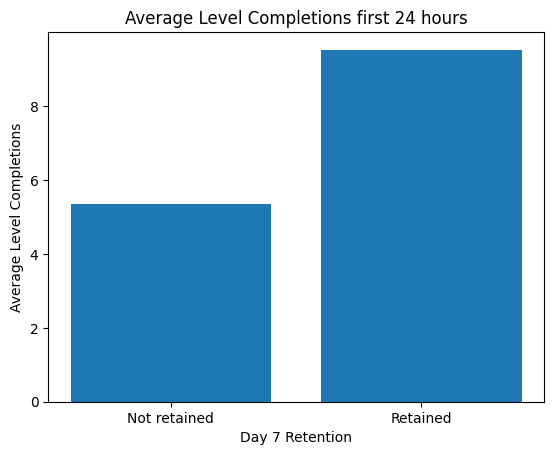

In [33]:
avg_completion = features.groupby("retained_7days")[["level_complete", "level_fail"]].mean()

plt.bar(["Not retained", "Retained"], avg_completion["level_complete"])

plt.xlabel("Day 7 Retention")
plt.ylabel("Average Level Completions")
plt.title("Average Level Completions first 24 hours")
plt.show()


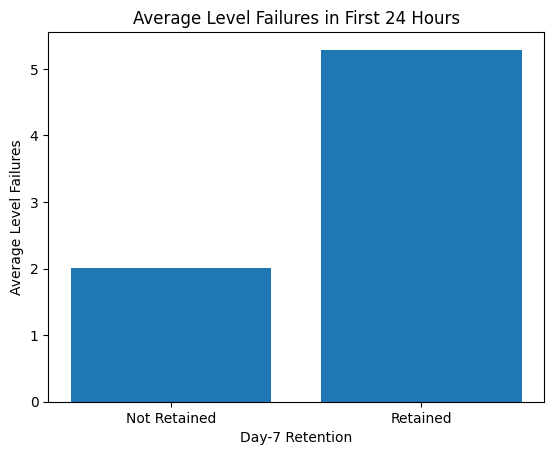

In [34]:
avg_fail = features.groupby("retained_7days")["level_fail"].mean()

plt.bar(["Not Retained", "Retained"], avg_fail)

plt.xlabel("Day-7 Retention")
plt.ylabel("Average Level Failures")
plt.title("Average Level Failures in First 24 Hours")
plt.show()

In [35]:
group_means = features.groupby("retained_7days")[["level_complete","level_fail"]].mean()

print(group_means)

                level_complete  level_fail
retained_7days                            
0                         5.35        2.01
1                         9.52        5.29


In [36]:
print(group_means.loc[1] - group_means.loc[0])

level_complete   4.17
level_fail       3.28
dtype: float64


Basic ML 

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
x = features[["level_complete", "level_fail"]]
y = features["retained_7days"]

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify= y)

In [40]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [41]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.6506024096385542


Evaluate machine mistakes

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[248  22]
 [123  22]]


Classification Report

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.92      0.77       270
           1       0.50      0.15      0.23       145

    accuracy                           0.65       415
   macro avg       0.58      0.54      0.50       415
weighted avg       0.61      0.65      0.58       415



In [44]:
df.to_csv("retention_analysis_cleaned.csv", index=False)